## **PAIR ASSIGNMENT**

Please work in pairs for this exercise. Pair up with the person next to you. If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand, and I will assist in pairing you with someone.


### **Task 0: Please assign your full name and your partner's full name to the variables below, respectively.**


Example:

```
your_name = 'Taylor Swift'
your_partner_name = 'Travis Kelce'
```

In [ ]:
# Assign your and your partner's names here.  If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand.
# If, in the end, we are unable to find a partner for you, please assign the word "self" to the `your_partner_name` variable.
your_name = 'Jonathan Cruz'
your_partner_name = 'self'

## **Attention Models for Next Word Prediction - Solution**

In this exercise, we'll build a small language model with PyTorch. The model will read a short sequence of words and predict the next word.

This is the same basic training objective used by decoder-only transformer models such as GPT:

$$P(\text{next word} \mid \text{previous words})$$

We will use:

- `nn.Embedding` to represent words as vectors
- Positional embeddings so the model knows word order
- `nn.MultiheadAttention` for masked self-attention
- `nn.LayerNorm`, `nn.Linear`, `nn.ReLU`, and `nn.Dropout` for the rest of a small transformer-style block


In [1]:
import math
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_20newsgroups
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)


## **1. Load the Dataset**

We'll use a subset of the 20 Newsgroups dataset. It is large enough to contain real language patterns, but small enough for an in-class activity.


In [2]:
categories = [
    "sci.space",
]

newsgroups = fetch_20newsgroups(
    data_home=".",
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),
)

print(f"Number of documents: {len(newsgroups.data)}")
print(f"Categories: {newsgroups.target_names}")
print(f"\nSample text:\n{newsgroups.data[0][:500]}")


Number of documents: 593
Categories: ['sci.space']

Sample text:

Any lunar satellite needs fuel to do regular orbit corrections, and when
its fuel runs out it will crash within months.  The orbits of the Apollo
motherships changed noticeably during lunar missions lasting only a few
days.  It is *possible* that there are stable orbits here and there --
the Moon's gravitational field is poorly mapped -- but we know of none.

Perturbations from Sun and Earth are relatively minor issues at low
altitudes.  The big problem is that the Moon's own gravitational fiel


## **2. Preprocess the Text**

For this first language model, we will predict words instead of subword tokens. We will:

1. Convert text to lowercase
2. Keep only letters and apostrophes
3. Split text into words
4. Keep a limited vocabulary of common words

Words outside the vocabulary will be mapped to a special `<unk>` token.


In [3]:
def preprocess_text(text):
    """Convert text to lowercase and split it into word tokens."""
    text = text.lower()
    text = re.sub(r"[^a-z'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()


all_words = []
for doc in newsgroups.data:
    all_words.extend(preprocess_text(doc))

print(f"Total words: {len(all_words):,}")
print(f"First 30 words: {all_words[:30]}")


Total words: 117,933
First 30 words: ['any', 'lunar', 'satellite', 'needs', 'fuel', 'to', 'do', 'regular', 'orbit', 'corrections', 'and', 'when', 'its', 'fuel', 'runs', 'out', 'it', 'will', 'crash', 'within', 'months', 'the', 'orbits', 'of', 'the', 'apollo', 'motherships', 'changed', 'noticeably', 'during']


## **3. Build the Vocabulary**

The model cannot process raw strings. We need to convert each word to an integer index.

We reserve two special tokens:

- `<pad>` for padding, if needed later
- `<unk>` for words not in our vocabulary


In [4]:
word_counts = Counter(all_words)
vocab_size = 5000

special_tokens = ["<pad>", "<unk>"]
most_common_words = [word for word, count in word_counts.most_common(vocab_size - len(special_tokens))]
vocab = special_tokens + most_common_words

word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

pad_idx = word_to_idx["<pad>"]
unk_idx = word_to_idx["<unk>"]

print(f"Vocabulary size: {len(vocab):,}")
print("Most common words:")
print(word_counts.most_common(20))

for word in ["space", "baseball", "computer", "government", "attention"]:
    print(f"{word:>12} -> {word_to_idx.get(word, unk_idx)}")


Vocabulary size: 5,000
Most common words:
[('the', 6324), ('of', 2968), ('to', 2856), ('a', 2640), ('and', 2604), ('in', 1828), ('is', 1519), ('for', 1282), ('that', 1102), ('on', 1024), ('space', 989), ('it', 964), ('i', 951), ('be', 848), ('are', 740), ('this', 737), ('you', 656), ('as', 640), ('have', 562), ('with', 561)]
       space -> 12
    baseball -> 1
    computer -> 509
  government -> 258
   attention -> 1608


## **4. Create Next-Word Training Examples**

Each training example will contain:

- **Input**: a sequence of `context_length` words
- **Target**: the word that comes immediately after that sequence

For example, with `context_length = 5`:

`[the, rocket, launched, from, cape] -> canaveral`


In [5]:
def words_to_indices(words, word_to_idx, unk_idx):
    return [word_to_idx.get(word, unk_idx) for word in words]


def create_next_word_examples(documents, context_length, max_examples=600000):
    examples = []
    targets = []

    for doc in documents:
        words = preprocess_text(doc)
        indices = words_to_indices(words, word_to_idx, unk_idx)

        if len(indices) <= context_length:
            continue

        for i in range(len(indices) - context_length):
            target = indices[i + context_length]
            if target == unk_idx:
                continue

            examples.append(indices[i : i + context_length])
            targets.append(target)

            if len(examples) >= max_examples:
                return examples, targets

    return examples, targets


context_length = 8
examples, targets = create_next_word_examples(newsgroups.data, context_length=context_length)

X = torch.tensor(examples, dtype=torch.long)
y = torch.tensor(targets, dtype=torch.long)

print(f"Input tensor shape: {X.shape}")
print(f"Target tensor shape: {y.shape}")


Input tensor shape: torch.Size([104456, 8])
Target tensor shape: torch.Size([104456])


In [6]:
for row in range(5):
    input_words = [idx_to_word[idx.item()] for idx in X[row]]
    target_word = idx_to_word[y[row].item()]
    print(f"{' '.join(input_words):<70} -> {target_word}")


any lunar satellite needs fuel to do regular                           -> orbit
lunar satellite needs fuel to do regular orbit                         -> corrections
satellite needs fuel to do regular orbit corrections                   -> and
needs fuel to do regular orbit corrections and                         -> when
fuel to do regular orbit corrections and when                          -> its


## **5. Create DataLoaders**

We'll split the examples into training and validation sets. The validation set gives us a rough sense of whether the model is learning patterns beyond memorizing the training examples.


In [7]:
num_examples = len(X)
indices = torch.randperm(num_examples)
train_size = int(0.8 * num_examples)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

X_train, y_train = X[train_indices], y[train_indices]
X_val, y_val = X[val_indices], y[val_indices]

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

print(f"Training examples: {len(X_train):,}")
print(f"Validation examples: {len(X_val):,}")


Training examples: 83,564
Validation examples: 20,892


## **6. Causal Self-Attention**

When predicting the next word, the model should only use the words in the context sequence. Inside the context sequence, token 1 should not attend to token 8.

A **causal mask** prevents each position from looking ahead to future positions.

PyTorch's `nn.MultiheadAttention` accepts an attention mask where masked positions are set to `-inf` before the softmax.


In [8]:
def make_causal_mask(sequence_length, device):
    """Create a mask that blocks attention to future positions."""
    return torch.triu(
        torch.full((sequence_length, sequence_length), float("-inf"), device=device),
        diagonal=1,
    )


mask = make_causal_mask(context_length, device="cpu")
print(mask)


tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


## **7. Define a Transformer-Style Model**

The model has four main parts:

1. Word embeddings
2. Positional embeddings
3. A masked self-attention block using `nn.MultiheadAttention`
4. A final linear layer that scores every possible next word

Important shape convention: we use `batch_first=True`, so tensors have shape:

`(batch_size, sequence_length, embedding_dim)`


In [9]:
class AttentionLanguageModel(nn.Module):
    def __init__(self, vocab_size, context_length, d_model=64, num_heads=4, d_ff=128, dropout=0.1):
        super(AttentionLanguageModel, self).__init__()
        self.context_length = context_length

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(context_length, d_model)

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch_size, sequence_length = x.shape
        positions = torch.arange(sequence_length, device=x.device).unsqueeze(0)

        token_vectors = self.token_embedding(x)
        position_vectors = self.position_embedding(positions)
        x = self.dropout(token_vectors + position_vectors)

        causal_mask = make_causal_mask(sequence_length, x.device)
        attention_output, attention_weights = self.attention(
            query=x,
            key=x,
            value=x,
            attn_mask=causal_mask,
            need_weights=True,
        )

        x = self.norm1(x + attention_output)
        feed_forward_output = self.feed_forward(x)
        x = self.norm2(x + feed_forward_output)

        last_token_representation = x[:, -1, :]
        logits = self.output_layer(last_token_representation)

        return logits, attention_weights


model = AttentionLanguageModel(
    vocab_size=len(vocab),
    context_length=context_length,
    d_model=64,
    num_heads=4,
    d_ff=128,
    dropout=0.1,
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


AttentionLanguageModel(
  (token_embedding): Embedding(5000, 64)
  (position_embedding): Embedding(8, 64)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (feed_forward): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (output_layer): Linear(in_features=64, out_features=5000, bias=True)
)

Total parameters: 678,984


## **8. Define the Loss Function and Optimizer**

This is a classification problem: the model chooses one next word from the vocabulary.

We'll use:

- `nn.CrossEntropyLoss` for multi-class classification
- `optim.AdamW`, a common optimizer for transformer-style models


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

print(f"Using device: {device}")


Using device: cpu


## **9. Train the Model**

The training loop follows the same PyTorch pattern as previous notebooks:

1. Move a batch to the device
2. Clear old gradients
3. Run a forward pass
4. Compute loss
5. Backpropagate
6. Update model parameters


In [11]:
def evaluate(model, data_loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits, _ = model(batch_x)
            loss = criterion(logits, batch_y)

            predictions = logits.argmax(dim=1)
            total_correct += (predictions == batch_y).sum().item()
            total_loss += loss.item() * batch_x.size(0)
            total_examples += batch_x.size(0)

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return avg_loss, accuracy


In [12]:
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_examples = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits, _ = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)
        total_examples += batch_x.size(0)

    train_loss = running_loss / total_examples
    val_loss, val_accuracy = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val accuracy: {val_accuracy:.2%}"
    )


Epoch 1/10 | train loss: 6.8779 | val loss: 6.5943 | val accuracy: 8.04%
Epoch 2/10 | train loss: 6.3801 | val loss: 6.3607 | val accuracy: 9.82%
Epoch 3/10 | train loss: 6.0409 | val loss: 6.2314 | val accuracy: 11.10%
Epoch 4/10 | train loss: 5.7558 | val loss: 6.1635 | val accuracy: 12.03%
Epoch 5/10 | train loss: 5.5157 | val loss: 6.1395 | val accuracy: 12.92%
Epoch 6/10 | train loss: 5.3199 | val loss: 6.1450 | val accuracy: 13.14%
Epoch 7/10 | train loss: 5.1580 | val loss: 6.1637 | val accuracy: 13.52%
Epoch 8/10 | train loss: 5.0167 | val loss: 6.1823 | val accuracy: 13.82%
Epoch 9/10 | train loss: 4.8982 | val loss: 6.2072 | val accuracy: 14.13%
Epoch 10/10 | train loss: 4.7954 | val loss: 6.2426 | val accuracy: 14.41%


## **10. Visualize Training Progress**

The loss should usually decrease over time. Next-word prediction is difficult, so do not expect high accuracy with a tiny model and only a few epochs.


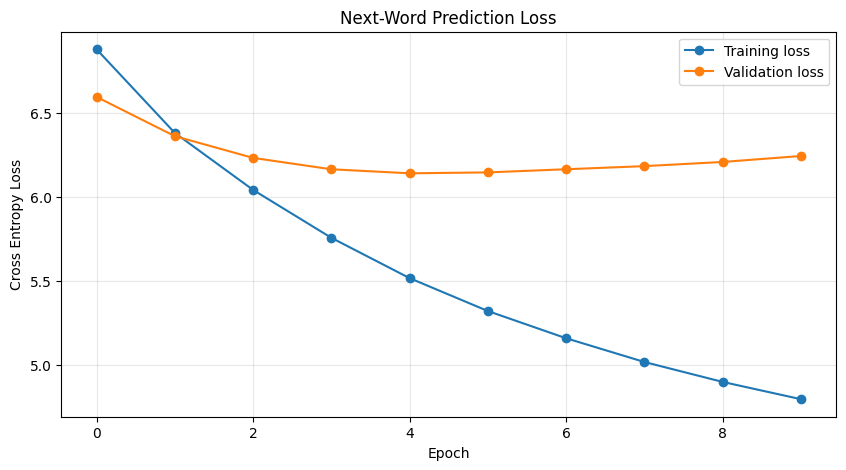

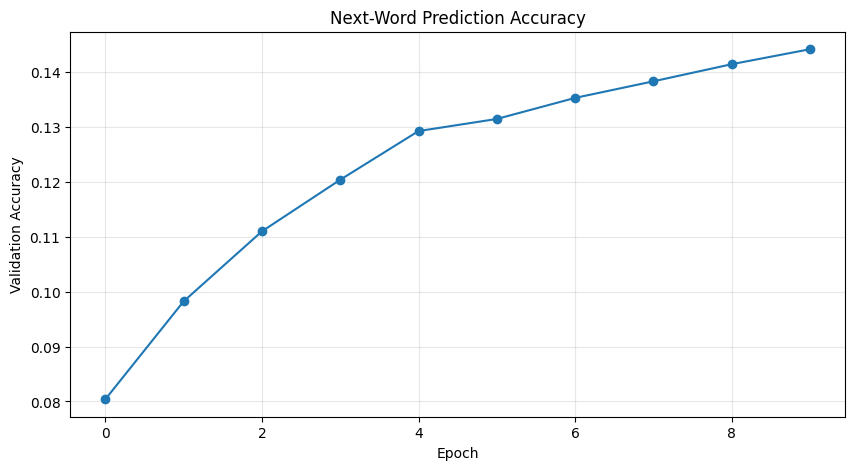

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, marker="o", label="Training loss")
plt.plot(val_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Next-Word Prediction Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(val_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Next-Word Prediction Accuracy")
plt.grid(True, alpha=0.3)
plt.show()


## **11. Predict the Next Word**

Now we can give the model a short prompt and ask it to predict likely next words.

The helper below keeps only the last `context_length` words, because that is the input size the model was trained on.


In [14]:
def predict_next_words(prompt, model, top_k=5):
    model.eval()
    words = preprocess_text(prompt)
    indices = words_to_indices(words, word_to_idx, unk_idx)

    if len(indices) < context_length:
        indices = [pad_idx] * (context_length - len(indices)) + indices
    else:
        indices = indices[-context_length:]

    x_prompt = torch.tensor([indices], dtype=torch.long).to(device)

    with torch.no_grad():
        logits, attention_weights = model(x_prompt)
        probabilities = torch.softmax(logits, dim=1).squeeze(0)
        top_probabilities, top_indices = torch.topk(probabilities, k=top_k)

    print(f"Prompt: {prompt}")
    print("Top predictions:")
    for probability, index in zip(top_probabilities.cpu(), top_indices.cpu()):
        print(f"  {idx_to_word[index.item()]:<15} {probability.item():.3f}")

    return attention_weights.cpu(), indices


attention_weights, prompt_indices = predict_next_words("the space shuttle was launched", model, top_k=10)


Prompt: the space shuttle was launched
Top predictions:
  in              0.133
  on              0.113
  by              0.092
  at              0.070
  to              0.054
  from            0.051
  into            0.037
  of              0.022
  but             0.021
  despite         0.021


In [16]:
test_prompts = [
    "the space shuttle launched from",
    "astronauts traveled to the",
    "the moon orbits the",
    "galaxies are composed of",
    "a massive star ends its life in a",
    "the mission to mars will",
    "black holes have a strong gravitational"
]

for prompt in test_prompts:
    predict_next_words(prompt, model, top_k=5)
    print()


Prompt: the space shuttle launched from
Top predictions:
  the             0.373
  earth           0.070
  a               0.037
  space           0.035
  an              0.018

Prompt: astronauts traveled to the
Top predictions:
  moon            0.043
  space           0.024
  lunar           0.023
  us              0.018
  net             0.012

Prompt: the moon orbits the
Top predictions:
  space           0.033
  universe        0.028
  moon            0.017
  earth           0.012
  lunar           0.010

Prompt: galaxies are composed of
Top predictions:
  the             0.229
  space           0.045
  a               0.031
  course          0.019
  this            0.016

Prompt: a massive star ends its life in a
Top predictions:
  few             0.049
  lot             0.019
  year            0.018
  small           0.016
  circular        0.016

Prompt: the mission to mars will
Top predictions:
  be              0.314
  allow           0.048
  have            0.029
  not     

## **12. Visualize Attention Weights**

Attention weights show how strongly each position attends to each other position.

Because we used a causal mask, the upper-right triangle should be blank or close to zero. A word should not attend to future words.


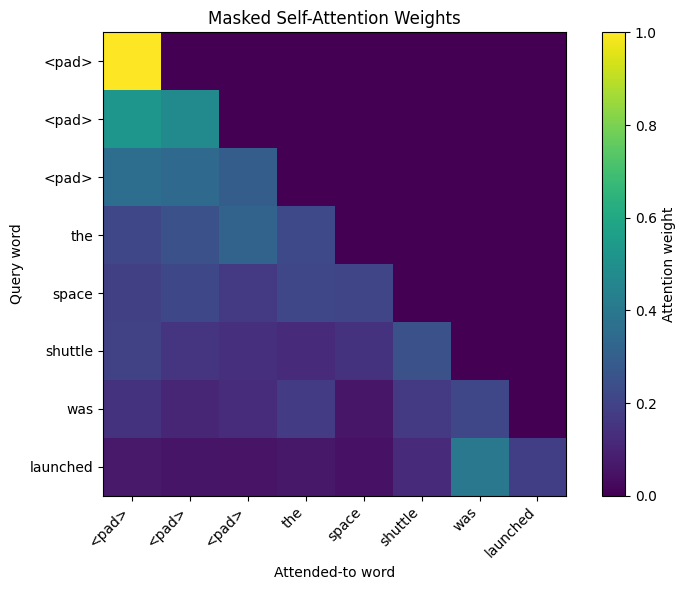

In [17]:
def plot_attention(attention_weights, token_indices):
    tokens = [idx_to_word[idx] for idx in token_indices]

    # With average_attn_weights=True, PyTorch returns shape (batch, target_len, source_len).
    weights = attention_weights[0].numpy()

    plt.figure(figsize=(8, 6))
    plt.imshow(weights, cmap="viridis")
    plt.colorbar(label="Attention weight")
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel("Attended-to word")
    plt.ylabel("Query word")
    plt.title("Masked Self-Attention Weights")
    plt.tight_layout()
    plt.show()


plot_attention(attention_weights, prompt_indices)


## **Summary**

In this exercise, you learned how to:

1. Turn raw text into word-index sequences
2. Create next-word prediction examples
3. Use `nn.Embedding` for word vectors
4. Add positional embeddings to represent word order
5. Use `nn.MultiheadAttention` for masked self-attention
6. Train a small transformer-style model with PyTorch
7. Inspect next-word predictions and attention weights
